Importação das bibliotecas:

In [9]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from io import StringIO
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

Carregar a base de dados:

In [10]:
url = "https://ourworldindata.org/grapher/share-of-adults-who-smoke.csv"

resposta = requests.get(url)
resposta.raise_for_status()

df = pd.read_csv(StringIO(resposta.text))

print("Colunas originais:")
print(df.columns)

Colunas originais:
Index(['Entity', 'Code', 'Year',
       'Share of adults who smoke or use tobacco (age-standardized)'],
      dtype='str')


Preparação e tratamento dos dados:

In [11]:
# Renomeando colunas
df = df.rename(columns={
    "Entity": "pais",
    "Code": "codigo_pais",
    "Year": "ano",
    "Share of adults who smoke or use tobacco (age-standardized)": "prevalencia"
})

print("\nColunas após renomeação:")
print(df.columns)

# Convertendo tipos
df["ano"] = pd.to_numeric(df["ano"], errors="coerce")
df["prevalencia"] = pd.to_numeric(df["prevalencia"], errors="coerce")

# Removendo valores nulos
df = df.dropna(subset=["pais", "codigo_pais", "ano", "prevalencia"])

# Mantendo apenas países com código ISO válido
df = df[df["codigo_pais"].astype(str).str.len() == 3]

print("\nPrimeiras linhas:")
print(df.head())


Colunas após renomeação:
Index(['pais', 'codigo_pais', 'ano', 'prevalencia'], dtype='str')

Primeiras linhas:
          pais codigo_pais   ano  prevalencia
0  Afghanistan         AFG  2000         39.2
1  Afghanistan         AFG  2005         34.2
2  Afghanistan         AFG  2007         32.5
3  Afghanistan         AFG  2010         30.2
4  Afghanistan         AFG  2015         26.6


Estatísticas descritivas:

In [12]:
print("\nEstatísticas descritivas:")
print(df["prevalencia"].describe())

print("\nValores ausentes:")
print(df[["pais", "codigo_pais", "ano", "prevalencia"]].isnull().sum())


Estatísticas descritivas:
count    1320.000000
mean       23.929924
std        11.266602
min         3.300000
25%        14.700000
50%        23.250000
75%        31.500000
max        68.000000
Name: prevalencia, dtype: float64

Valores ausentes:
pais           0
codigo_pais    0
ano            0
prevalencia    0
dtype: int64


Distribuição da prevalência (histograma):

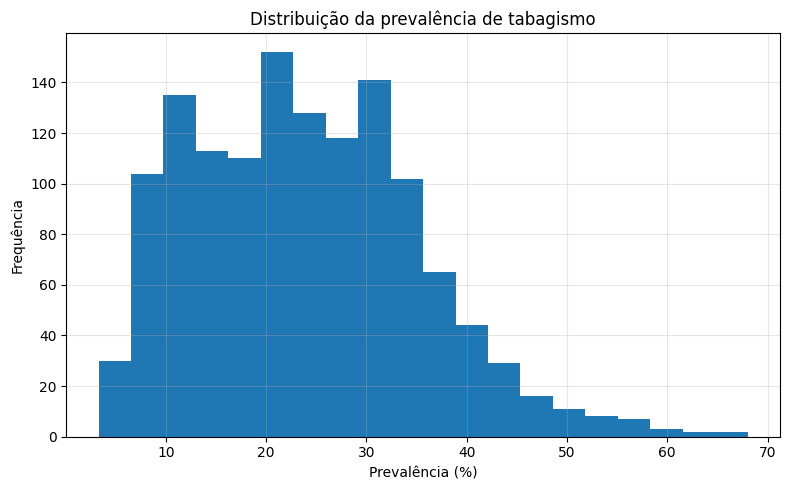

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df["prevalencia"], bins=20)
plt.title("Distribuição da prevalência de tabagismo")
plt.xlabel("Prevalência (%)")
plt.ylabel("Frequência")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Top 10 países com maior prevalência:

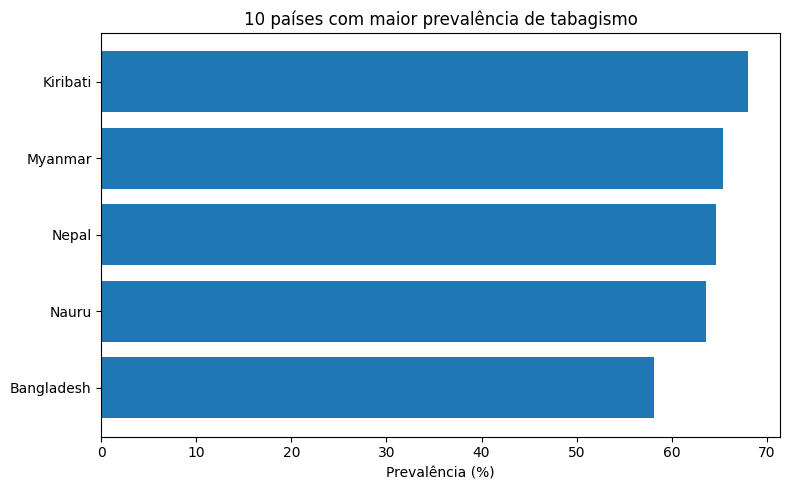


Top 10 países:
           pais  prevalencia
672    Kiribati         68.0
880     Myanmar         65.4
904       Nepal         64.7
896       Nauru         63.6
673    Kiribati         60.5
881     Myanmar         60.5
897       Nauru         59.6
882     Myanmar         58.2
104  Bangladesh         58.1
898       Nauru         57.8


In [14]:
top10 = df.sort_values("prevalencia", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["pais"], top10["prevalencia"])
plt.gca().invert_yaxis()
plt.title("10 países com maior prevalência de tabagismo")
plt.xlabel("Prevalência (%)")
plt.tight_layout()
plt.show()

print("\nTop 10 países:")
print(top10[["pais", "prevalencia"]])

Top 10 países com menor prevalência:

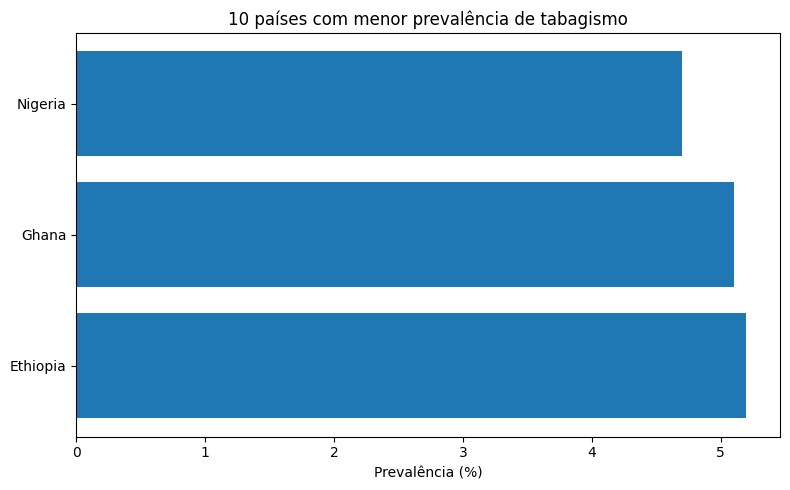


Bottom 10 países:
         pais  prevalencia
943   Nigeria          3.3
503     Ghana          3.4
942   Nigeria          3.4
502     Ghana          3.5
501     Ghana          3.6
941   Nigeria          3.6
500     Ghana          4.3
940   Nigeria          4.7
499     Ghana          5.1
439  Ethiopia          5.2


In [15]:
bottom10 = df.sort_values("prevalencia", ascending=True).head(10)

plt.figure(figsize=(8,5))
plt.barh(bottom10["pais"], bottom10["prevalencia"])
plt.gca().invert_yaxis()
plt.title("10 países com menor prevalência de tabagismo")
plt.xlabel("Prevalência (%)")
plt.tight_layout()
plt.show()

print("\nBottom 10 países:")
print(bottom10[["pais", "prevalencia"]])

Evolução da prevalência ao longo do tempo:

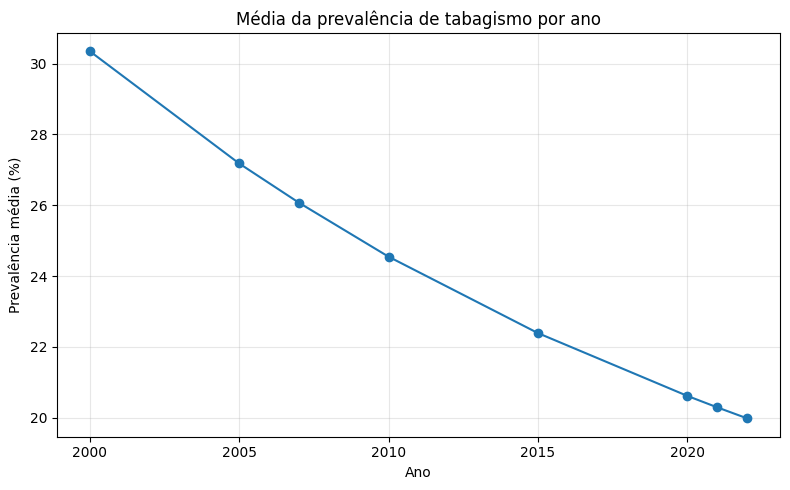

In [16]:
media_ano = df.groupby("ano")["prevalencia"].mean()

plt.figure(figsize=(8,5))
plt.plot(media_ano.index, media_ano.values, marker="o")
plt.title("Média da prevalência de tabagismo por ano")
plt.xlabel("Ano")
plt.ylabel("Prevalência média (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Análise do ano mais recente:

In [17]:
ano_mais_recente = int(df["ano"].max())
df_recente = df[df["ano"] == ano_mais_recente]

print("\nAno mais recente:", ano_mais_recente)
print("Quantidade de registros:", len(df_recente))


Ano mais recente: 2022
Quantidade de registros: 165


Salvando os dados e gráficos:

In [18]:
# Criando pastas
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("reports/figures").mkdir(parents=True, exist_ok=True)

# Salvando dados
df.to_csv("data/processed/dados_tratados.csv", index=False)
df_recente.to_csv("data/processed/dados_recentes.csv", index=False)

print("\nDados salvos com sucesso.")


Dados salvos com sucesso.


Conclusão:

In [19]:
print("""
A análise exploratória de dados (EDA) foi concluída com sucesso.

Foram identificados padrões relevantes na prevalência do tabagismo,
incluindo sua distribuição entre países e sua evolução ao longo do tempo.

Os dados indicam uma tendência geral de redução da prevalência global,
embora ainda existam países com níveis elevados.

Os dados tratados e gráficos foram salvos para uso nas próximas etapas do projeto.
""")


A análise exploratória de dados (EDA) foi concluída com sucesso.

Foram identificados padrões relevantes na prevalência do tabagismo,
incluindo sua distribuição entre países e sua evolução ao longo do tempo.

Os dados indicam uma tendência geral de redução da prevalência global,
embora ainda existam países com níveis elevados.

Os dados tratados e gráficos foram salvos para uso nas próximas etapas do projeto.

